In [ ]:
#import numpy for numerical operations 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
!pip install keras-tuner
import keras_tuner as kt 
import os

In [ ]:
print(tf.__version__)
os.getcwd()

2.19.0


'/content'

In [ ]:
# Try loading from local directory first, otherwise download the dataset
import urllib.request, zipfile

csv_filename = "AirQualityUCI.csv"
if not os.path.exists(csv_filename):
    print("CSV not found locally, downloading...")
    url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
    urllib.request.urlretrieve(url, "air_quality.zip")
    with zipfile.ZipFile("air_quality.zip", "r") as z:
        z.extractall(".")
    print("Download complete!")

df = pd.read_csv(csv_filename, sep=";", decimal=",")
print(f"Dataset loaded: {df.shape}")

Dataset loaded: (9471, 17)


In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [ ]:
df.shape

(9471, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [ ]:
print(df.head())
print(df.shape)
df.info()


         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  Unnamed: 15  Unnamed: 16  
0  13.6  48.9  0.7578          NaN          NaN  
1  13.3  47.7  0

In [ ]:
df.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


In [ ]:
# Drop the two unnamed empty columns:
df.drop(columns=[col for col in df.columns if col.startswith("Unnamed")], inplace=True)

# 2. Drop the Date and Time columns (not useful for prediction):
df.drop(columns=["Date", "Time"], inplace=True, errors="ignore")

# 3. Replace all -200 values with NaN:
df.replace(-200, np.nan, inplace=True)

df.isnull().sum()

,0
CO(GT),1797
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),480
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756
PT08.S4(NO2),480
PT08.S5(O3),480


In [ ]:
df.drop(columns=["NMHC(GT)", "Time"], inplace=True, errors="ignore")
df.isnull().sum()

,0
CO(GT),1797
PT08.S1(CO),480
C6H6(GT),480
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756
PT08.S4(NO2),480
PT08.S5(O3),480
T,480


In [ ]:

df.fillna(df.mean(numeric_only=True), inplace=True)
df.isnull().sum()

,0
CO(GT),0
PT08.S1(CO),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0
PT08.S4(NO2),0
PT08.S5(O3),0
T,0


In [ ]:
# spliting data to input and output
X = df.drop(columns=['CO(GT)'])
y = df['CO(GT)']

In [ ]:
X

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1360.000000,11.900000,1046.000000,166.000000,1056.000000,113.000000,1692.000000,1268.000000,13.600000,48.900000,0.75780
1,1292.000000,9.400000,955.000000,103.000000,1174.000000,92.000000,1559.000000,972.000000,13.300000,47.700000,0.72550
2,1402.000000,9.000000,939.000000,131.000000,1140.000000,114.000000,1555.000000,1074.000000,11.900000,54.000000,0.75020
3,1376.000000,9.200000,948.000000,172.000000,1092.000000,122.000000,1584.000000,1203.000000,11.000000,60.000000,0.78670
4,1272.000000,6.500000,836.000000,131.000000,1205.000000,116.000000,1490.000000,1110.000000,11.200000,59.600000,0.78880
...,...,...,...,...,...,...,...,...,...,...,...
9466,1099.833166,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.02553
9467,1099.833166,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.02553
9468,1099.833166,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.02553
9469,1099.833166,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.02553


In [ ]:
y

,CO(GT)
0,2.60000
1,2.00000
2,2.20000
3,2.20000
4,1.60000
...,...
9466,2.15275
9467,2.15275
9468,2.15275
9469,2.15275


In [ ]:
# 2. Split into training and testing sets (80/20 ratio):
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3. Apply StandardScaler to the features:
# Important: fit_transform on training data, but only transform on test data. This prevents data leakage.
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
# 4. Verify by printing shapes:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (7576, 11)
X_test shape: (1895, 11)
y_train shape: (7576,)
y_test shape: (1895,)


In [ ]:
baseline_model = Sequential([
    Dense(64, activation='relu', input_shape=(11,)),
    Dense(32, activation='relu'),
    Dense(1,activation='linear')
]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
baseline_model.compile(optimizer='adam',loss='mse', metrics=['mae'])

In [ ]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.5479 - mae: 1.1923 - val_loss: 0.4693 - val_mae: 0.4944
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.5479 - mae: 1.1923 - val_loss: 0.4693 - val_mae: 0.4944
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3831 - mae: 0.4477 - val_loss: 0.3695 - val_mae: 0.4324
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3831 - mae: 0.4477 - val_loss: 0.3695 - val_mae: 0.4324
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3566 - mae: 0.4111 - val_loss: 0.3552 - val_mae: 0.4026
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3566 - mae: 0.4111 - val_loss: 0.3552 - val_mae: 0.4026
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3082 - mae: 0.3809 - val_loss: 0.3402 - val_mae: 0.3945
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3082 - mae: 0.3809 - val_loss: 0.3402 - val_mae: 0.3945
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

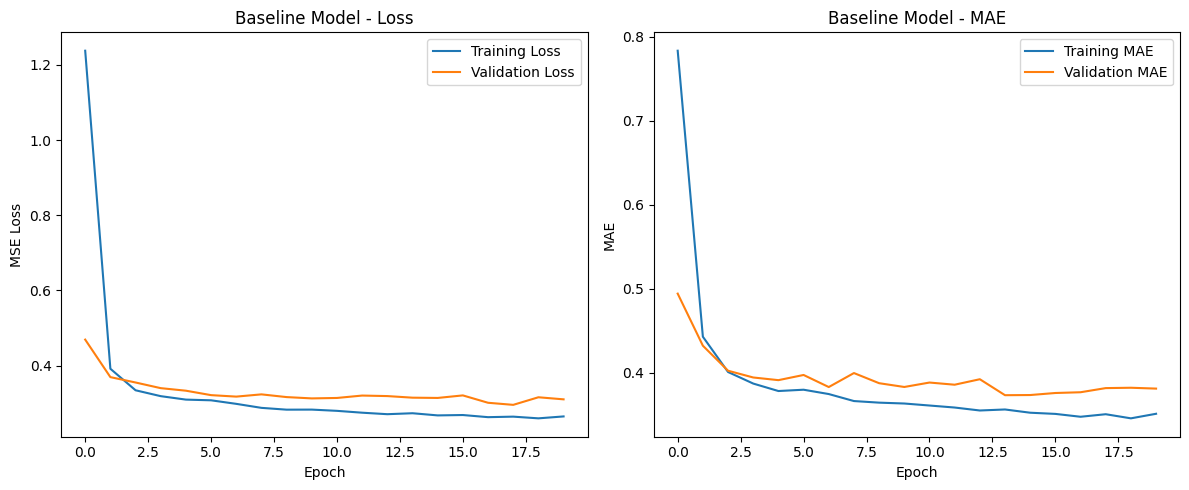

In [ ]:
# Plot 1: Loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# Plot 2: MAE curves
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['mae'], label='Training MAE')
plt.plot(baseline_history.history['val_mae'], label='Validation MAE')
plt.title('Baseline Model - MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
regularized_model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(11,)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='linear')
])

regularized_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
regularized_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,937 (15.38 KB)

 Trainable params: 3,937 (15.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_baseline_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the regularized model
reg_history = regularized_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.0142 - mae: 1.3566
Epoch 1: val_loss improved from inf to 1.33065, saving model to best_baseline_model.keras

Epoch 1: val_loss improved from inf to 1.33065, saving model to best_baseline_model.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 4.0073 - mae: 1.3548 - val_loss: 1.3307 - val_mae: 0.5865
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 4.0073 - mae: 1.3548 - val_loss: 1.3307 - val_mae: 0.5865
Epoch 2/20
181/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5840 - mae: 0.6946
Epoch 2: val_loss improved from 1.33065 to 1.00245, saving model to best_baseline_model.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5792 - mae: 0.6932 - val_loss: 1.0025 - val_mae: 0.4690
Epoch 3/20
  1/190 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 1.7873 - mae: 0.7525
Epoch 2: val_loss improved from 1.33065 to 1.00245, saving model to best_baseline_model.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5

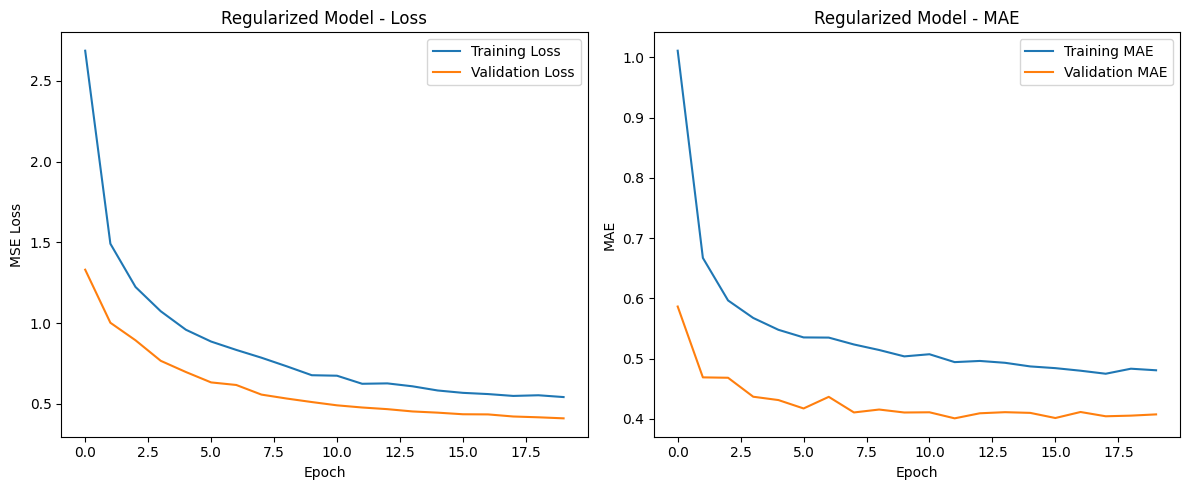

In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(reg_history.history['loss'], label='Training Loss')
plt.plot(reg_history.history['val_loss'], label='Validation Loss')
plt.title('Regularized Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# Plot 2: MAE
plt.subplot(1, 2, 2)
plt.plot(reg_history.history['mae'], label='Training MAE')
plt.plot(reg_history.history['val_mae'], label='Validation MAE')
plt.title('Regularized Model - MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()